# Análise Exploratória de Dados (EDA)
## Tech Challenge Fase 1 — Saúde Feminina

**Dataset:** Breast Cancer Wisconsin Diagnostic Dataset  
**Fonte:** [Kaggle — UCI ML Breast Cancer Wisconsin](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data)

**Problema:** Classificar tumores de mama como **malignos (M)** ou **benignos (B)** a partir de características extraídas de imagens de aspiração por agulha fina (FNA) de massas mamárias.

Este notebook realiza a análise exploratória completa: carregamento, inspeção inicial, estatísticas descritivas, distribuições, correlações e identificação de padrões clínicos relevantes.

## 1. Imports e configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42

## 2. Carregamento dos dados

In [2]:
df = pd.read_csv('../data/raw/data.csv')

# Remove coluna vazia gerada pelo dataset original
df.drop(columns=['Unnamed: 32'], inplace=True, errors='ignore')

print(f'Shape: {df.shape}')
df.head()

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Inspeção inicial

In [3]:
print('=== Tipos de dados ===')
print(df.dtypes)
print(f'\nTotal de amostras : {df.shape[0]}')
print(f'Total de features : {df.shape[1] - 2}  (excluindo id e diagnosis)')

=== Tipos de dados ===
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float

In [4]:
print('=== Valores ausentes ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Nenhum valor ausente encontrado.')

=== Valores ausentes ===
Nenhum valor ausente encontrado.


In [5]:
print('=== Duplicatas ===')
print(f'Linhas duplicadas: {df.duplicated().sum()}')

=== Duplicatas ===
Linhas duplicadas: 0


## 4. Variável alvo — distribuição de classes

In [6]:
counts = df['diagnosis'].value_counts()
pct    = df['diagnosis'].value_counts(normalize=True) * 100

print('Distribuição da variável alvo:')
print(pd.DataFrame({'Contagem': counts, 'Percentual (%)': pct.round(1)}))

Distribuição da variável alvo:
           Contagem  Percentual (%)
diagnosis                          
B               357            62.7
M               212            37.3


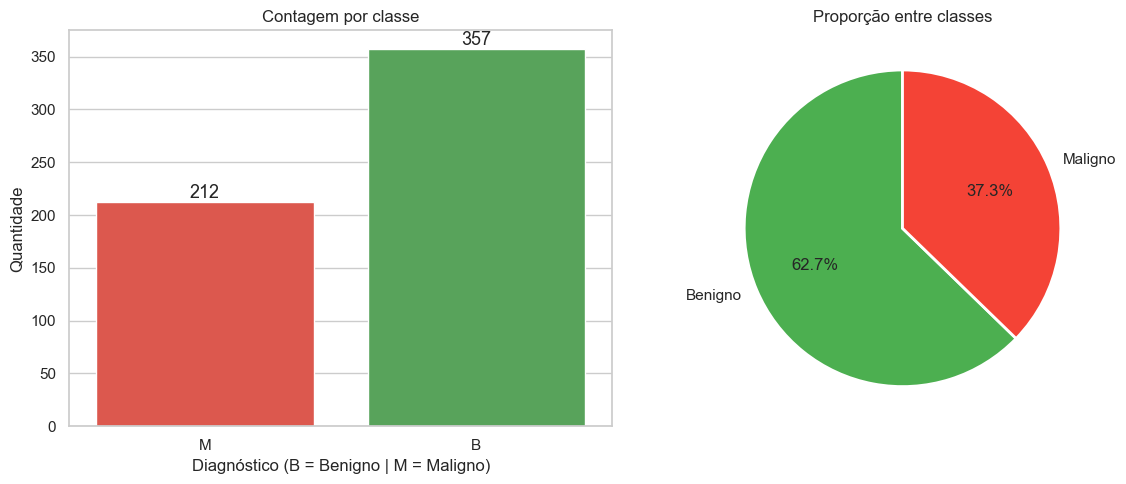

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
sns.countplot(data=df, x='diagnosis', ax=axes[0],
              palette={'B': '#4CAF50', 'M': '#F44336'})
axes[0].set_title('Contagem por classe')
axes[0].set_xlabel('Diagnóstico (B = Benigno | M = Maligno)')
axes[0].set_ylabel('Quantidade')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=13)

# Pizza
axes[1].pie(counts, labels=['Benigno', 'Maligno'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção entre classes')

plt.tight_layout()
plt.savefig('../reports/figures/01_distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

**Observação:** O dataset apresenta leve desbalanceamento (~63% benignos vs ~37% malignos). Este ponto será considerado durante a modelagem, priorizando métricas como **Recall** para a classe maligna — um falso negativo (tumor maligno classificado como benigno) tem consequências clínicas graves.

## 5. Estatísticas descritivas

In [8]:
# Separar features por grupo
features_mean   = [c for c in df.columns if c.endswith('_mean')]
features_se     = [c for c in df.columns if c.endswith('_se')]
features_worst  = [c for c in df.columns if c.endswith('_worst')]

print(f'Features _mean  : {len(features_mean)}')
print(f'Features _se    : {len(features_se)}')
print(f'Features _worst : {len(features_worst)}')

df[features_mean].describe().T.style.background_gradient(cmap='Blues')

Features _mean  : 10
Features _se    : 10
Features _worst : 10


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
fractal_dimension_mean,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


## 6. Distribuição das features — por classe

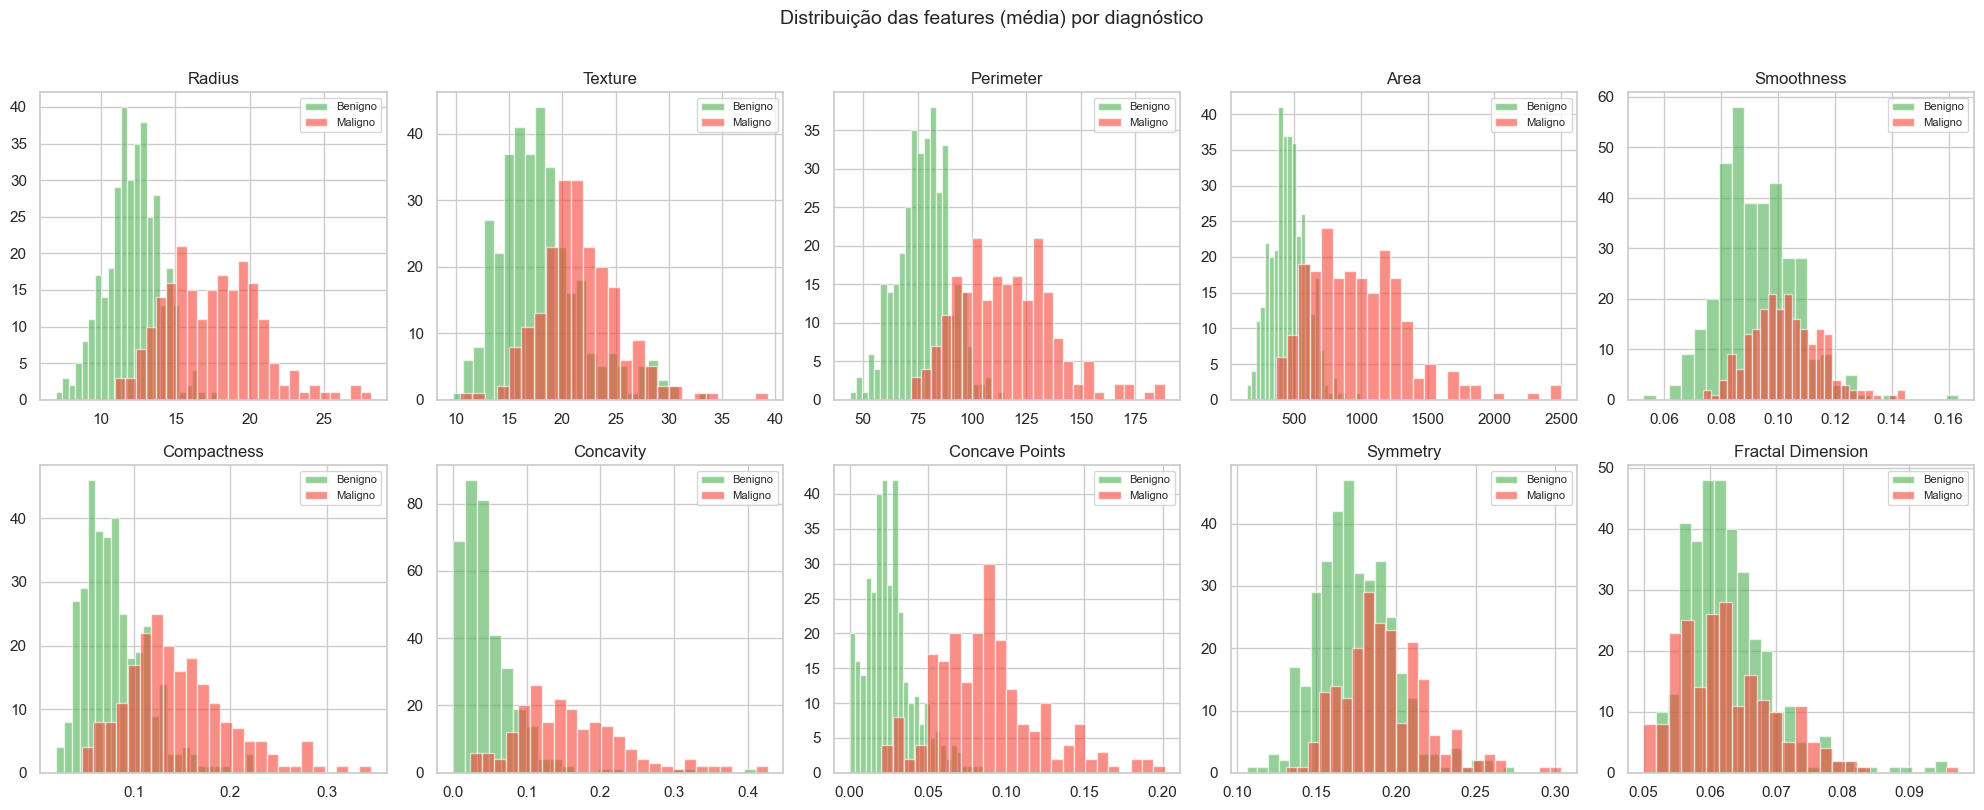

In [9]:
palette = {'B': '#4CAF50', 'M': '#F44336'}

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(features_mean):
    for label, color in palette.items():
        subset = df[df['diagnosis'] == label][feat]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color,
                     label='Benigno' if label == 'B' else 'Maligno', edgecolor='white')
    axes[i].set_title(feat.replace('_mean', '').replace('_', ' ').title())
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das features (média) por diagnóstico', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/02_distribuicao_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Boxplots — separação entre classes

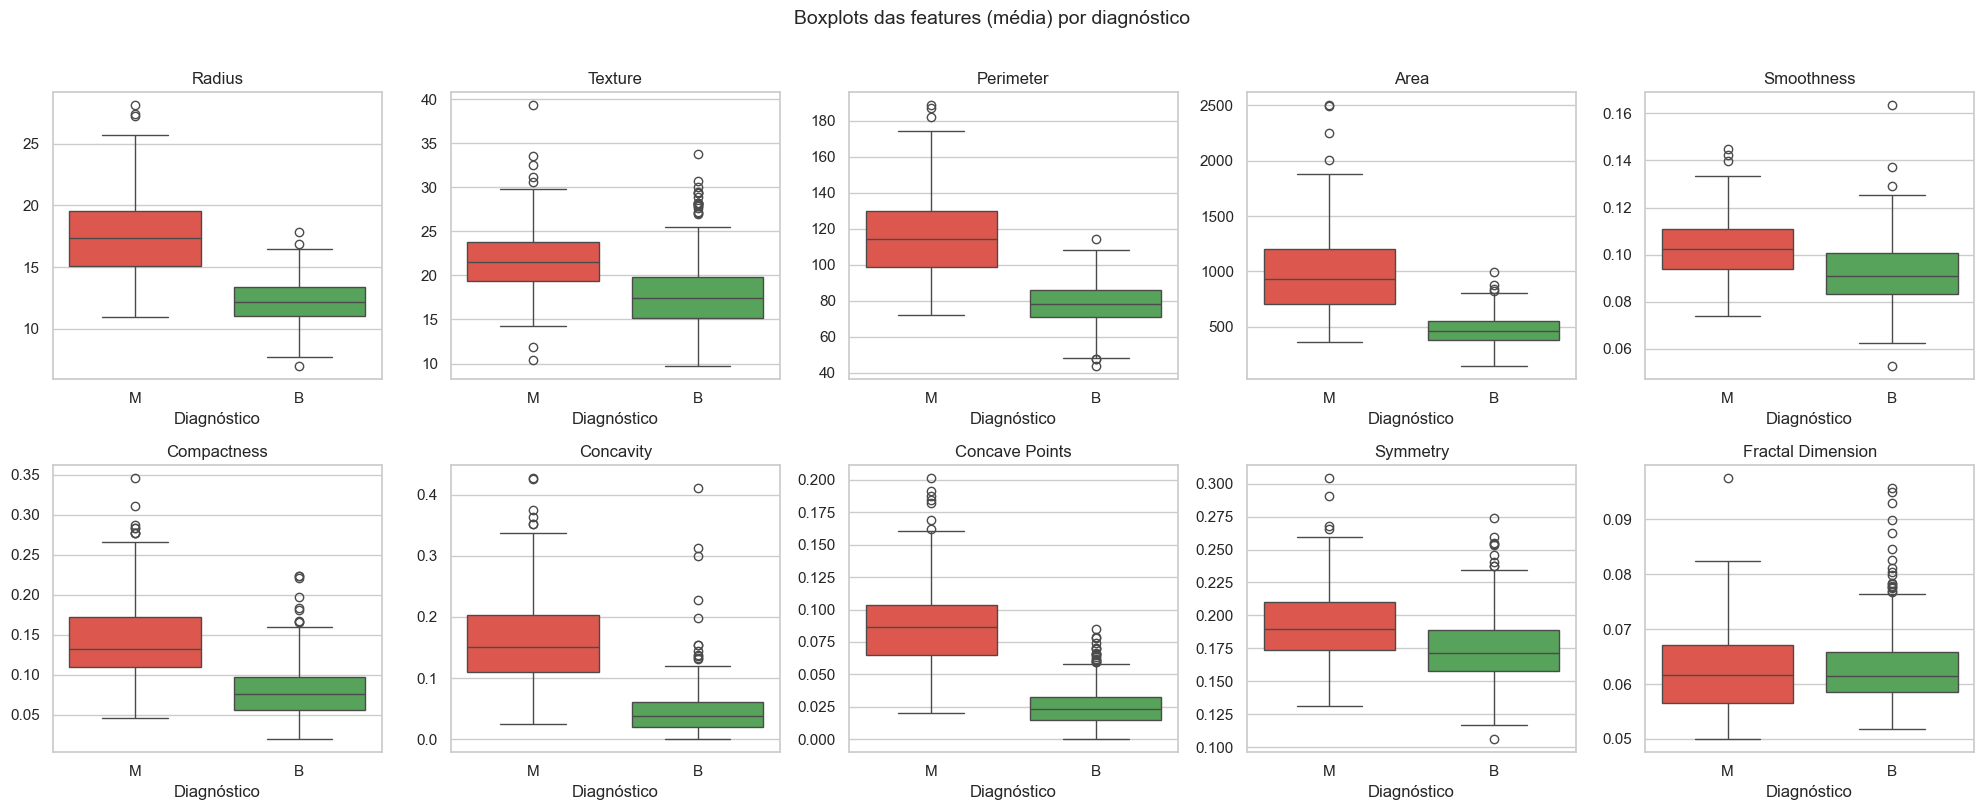

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(features_mean):
    sns.boxplot(data=df, x='diagnosis', y=feat, ax=axes[i],
                palette={'B': '#4CAF50', 'M': '#F44336'})
    axes[i].set_title(feat.replace('_mean', '').replace('_', ' ').title())
    axes[i].set_xlabel('Diagnóstico')
    axes[i].set_ylabel('')

plt.suptitle('Boxplots das features (média) por diagnóstico', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/03_boxplots_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análise de correlação

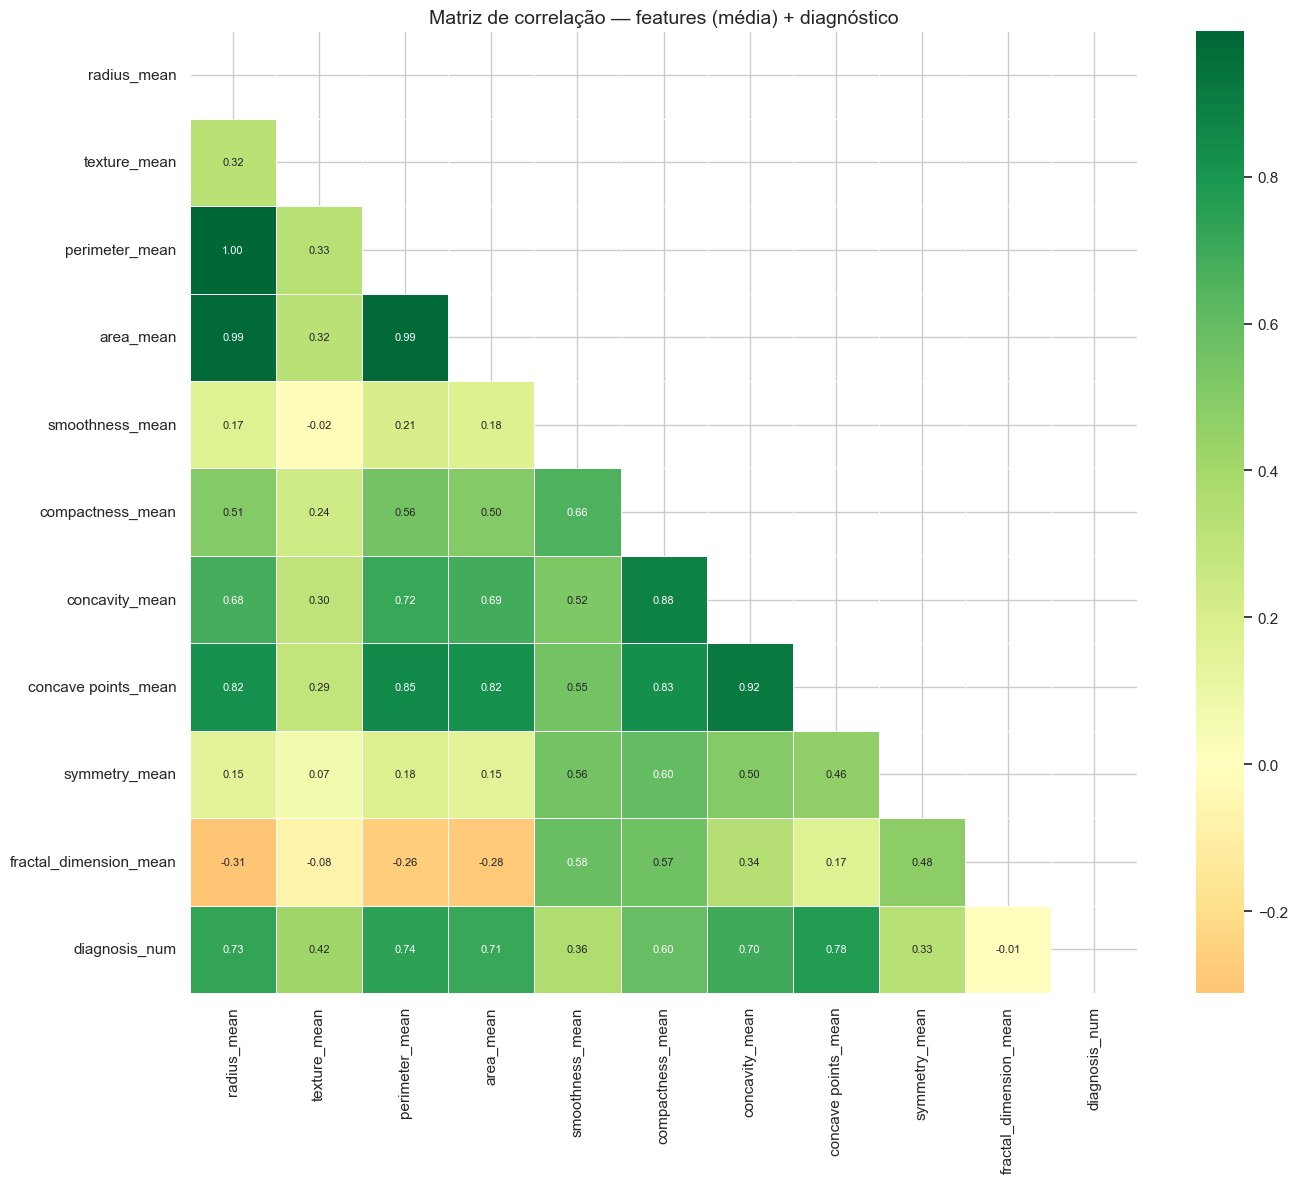

In [11]:
# Codificar target para correlação numérica
df_corr = df.copy()
df_corr['diagnosis_num'] = df_corr['diagnosis'].map({'B': 0, 'M': 1})

corr_matrix = df_corr[features_mean + ['diagnosis_num']].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Matriz de correlação — features (média) + diagnóstico', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/04_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

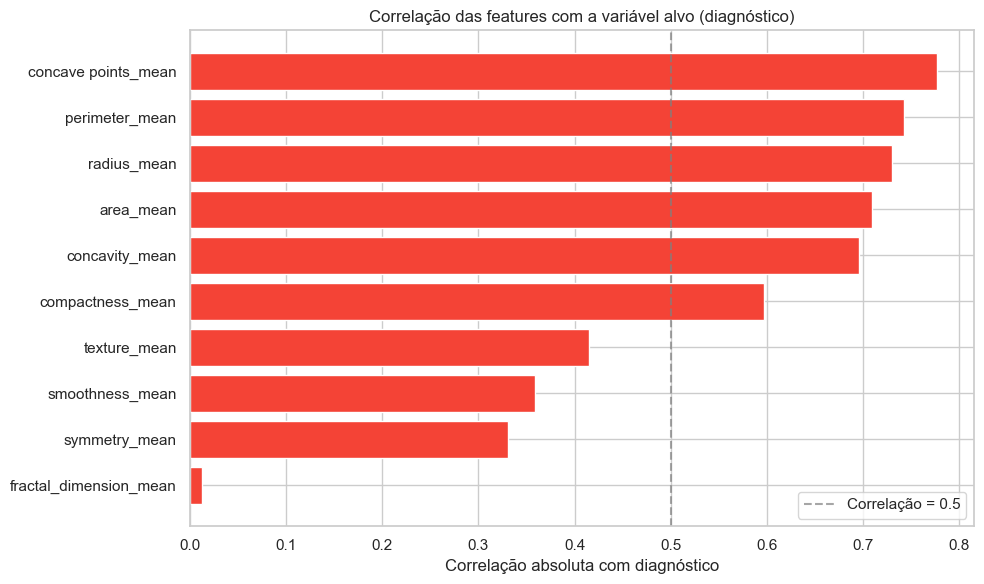


Top 5 features mais correlacionadas com diagnóstico maligno:
concave points_mean    0.776614
perimeter_mean         0.742636
radius_mean            0.730029
area_mean              0.708984
concavity_mean         0.696360
Name: diagnosis_num, dtype: float64


In [12]:
# Features com maior correlação com o diagnóstico
corr_target = df_corr[features_mean + ['diagnosis_num']].corr()['diagnosis_num'].drop('diagnosis_num')
corr_target_sorted = corr_target.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(corr_target_sorted.index[::-1],
                corr_target_sorted.values[::-1],
                color=['#F44336' if v > 0 else '#4CAF50' for v in corr_target_sorted.values[::-1]])
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Correlação = 0.5')
plt.xlabel('Correlação absoluta com diagnóstico')
plt.title('Correlação das features com a variável alvo (diagnóstico)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/05_correlacao_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features mais correlacionadas com diagnóstico maligno:')
print(corr_target.reindex(corr_target_sorted.index).head())

## 9. Pairplot — features mais relevantes

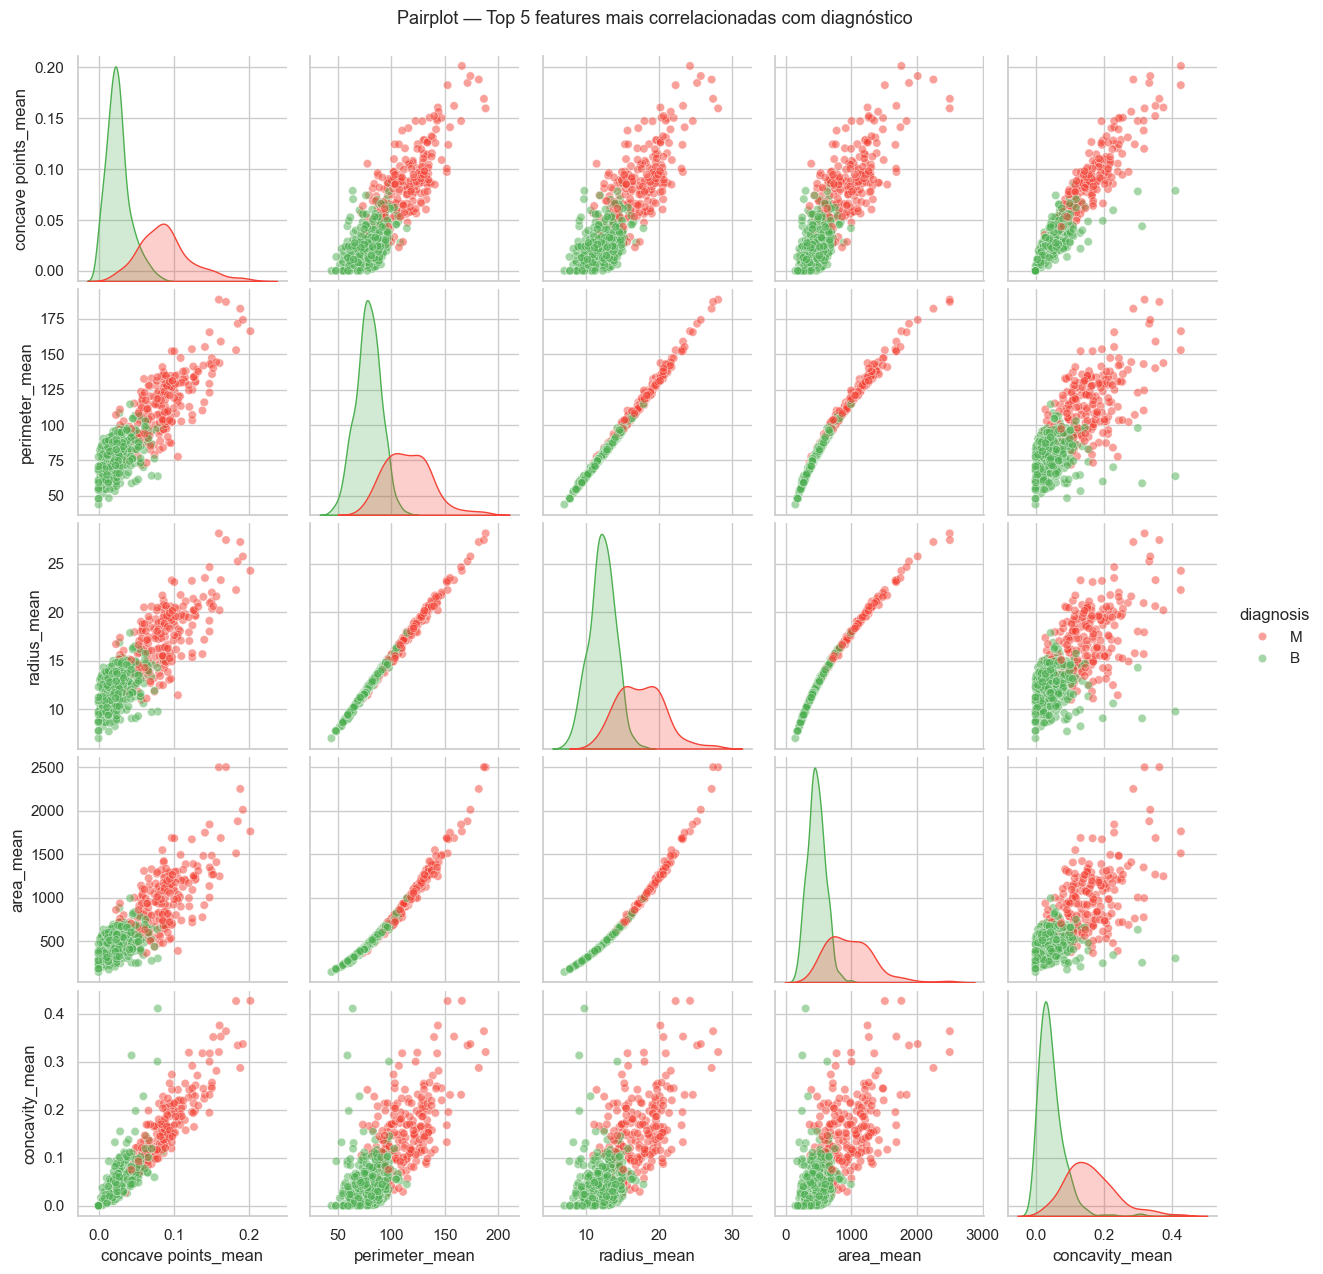

In [13]:
top_features = corr_target_sorted.head(5).index.tolist()

pair_df = df[top_features + ['diagnosis']].copy()

g = sns.pairplot(pair_df, hue='diagnosis',
                 palette={'B': '#4CAF50', 'M': '#F44336'},
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('Pairplot — Top 5 features mais correlacionadas com diagnóstico', y=1.02, fontsize=13)
plt.savefig('../reports/figures/06_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Análise por grupo de estatísticas (mean / se / worst)

In [14]:
groups = {'Média (_mean)': features_mean, 'Erro padrão (_se)': features_se, 'Pior (_worst)': features_worst}

for group_name, feats in groups.items():
    corr_g = df_corr[feats + ['diagnosis_num']].corr()['diagnosis_num'].drop('diagnosis_num')
    best = corr_g.abs().idxmax()
    print(f'{group_name}: feature mais correlacionada → {best} ({corr_g[best]:.3f})')

Média (_mean): feature mais correlacionada → concave points_mean (0.777)
Erro padrão (_se): feature mais correlacionada → radius_se (0.567)
Pior (_worst): feature mais correlacionada → concave points_worst (0.794)


## 11. Insights e conclusões da EDA

### Qualidade dos dados
- **Sem valores ausentes** nem duplicatas — o dataset está limpo e pronto para modelagem com pré-processamento mínimo.
- A coluna `id` é um identificador sem valor preditivo e será removida no pré-processamento.
- A coluna `Unnamed: 32` estava completamente vazia e foi descartada.

### Distribuição de classes
- O dataset apresenta **leve desbalanceamento** (~63% benigno / ~37% maligno).
- No contexto clínico, o custo de um **falso negativo** (não detectar um tumor maligno) é muito maior do que um falso positivo.
- Isso justifica o uso do **Recall** como métrica principal na avaliação dos modelos.

### Features mais discriminativas
- As features de **área**, **perímetro** e **concavidade** apresentam a maior separação entre tumores malignos e benignos.
- Tumores malignos tendem a ser maiores, mais irregulares e com maior concavidade — o que é clinicamente consistente com a literatura médica.
- Há alta **multicolinearidade** entre várias features (especialmente área, raio e perímetro), o que deverá ser tratado na etapa de pré-processamento.

### Próximos passos
- Remover `id`, codificar `diagnosis` (B→0, M→1)
- Aplicar padronização (StandardScaler) — necessária especialmente para Regressão Logística e KNN
- Avaliar remoção de features altamente correlacionadas entre si
- Split treino/teste estratificado para preservar proporção das classes